# Laboratorio Semana 3: LSTM desde cero con PyTorch

**Curso:** Deep Learning  
**Valor:** 4% de la nota del curso  
**Entrega:** Notebook ejecutado (.ipynb) con todas las celdas con salida visible
**Integrantes:** Vianka Castro 23201, Ricardo Godínez 23247

---

## Contexto

Esta semana usted va a implementar un LSTM completo desde cero usando tensores de PyTorch: forward pass, backward pass manual y actualizacion de pesos. La tarea es clasificacion binaria sobre una secuencia sintetica: determinar si una secuencia de pares de numeros tiene tendencia creciente (etiqueta 1) o decreciente (etiqueta 0).

La arquitectura es la siguiente:

```
Secuencia x_1,...,x_T  ->  LSTM (T pasos)  ->  h_T  ->  Dense + sigmoid  ->  y_hat  ->  BCE
```

Es una arquitectura **many-to-one**: el LSTM lee toda la secuencia y solo la salida del ultimo paso $h_T$ se usa para clasificar.

## Reglas

- Use **unicamente PyTorch** para operaciones tensoriales. No use `nn.LSTM`, `nn.RNNCell`, `nn.Linear` ni ninguna capa de alto nivel.
- El backward pass debe ser **manual**: calcule cada gradiente a mano aplicando la regla de la cadena. No use `loss.backward()`.
- Las celdas marcadas con `# SU CODIGO AQUI` son las que debe completar.
- **No modifique las celdas de verificacion ni los pesos iniciales.**
- La celda final calcula su nota automatica sobre los **53 puntos** de la seccion de codigo.

In [1]:
import torch
import hashlib
import numpy as np
import matplotlib.pyplot as plt

def _hash_tensor(t, decimals=5):
    """Huella criptografica reproducible de un tensor PyTorch."""
    arr = np.round(t.detach().numpy().astype(np.float64), decimals)
    return hashlib.sha256(arr.tobytes()).hexdigest()

_resultados = {}
print("Librerias cargadas.")
print(f"PyTorch version: {torch.__version__}")

Librerias cargadas.
PyTorch version: 2.13.0+cpu


---
## Bloque 0: Datos y pesos iniciales (dado, no modificar)

La secuencia de entrada tiene $T=5$ pasos, cada uno un vector de dimension $n=2$.  
La dimension del hidden state es $d=4$.  
La etiqueta es $y=1$ (secuencia creciente).  

**No modifique los pesos iniciales**: el autograder depende de estos valores exactos.

In [2]:
# Datos
x_seq = torch.tensor([
    [0.1, 0.2],
    [0.3, 0.4],
    [0.5, 0.6],
    [0.7, 0.8],
    [0.9, 1.0],
], dtype=torch.float32)   # forma: (T=5, n=2)

label = torch.tensor([1.0])   # secuencia creciente

# Dimensiones
T = 5    # largo de la secuencia
n = 2    # dimension de entrada
d = 4    # dimension del hidden state

# Pesos iniciales fijos (torch.manual_seed(0))
torch.manual_seed(0)
W_f = torch.randn(d, d+n) * 0.1   # forget gate     (4, 6)
b_f = torch.zeros(d)
W_i = torch.randn(d, d+n) * 0.1   # input gate      (4, 6)
b_i = torch.zeros(d)
W_c = torch.randn(d, d+n) * 0.1   # candidato       (4, 6)
b_c = torch.zeros(d)
W_o = torch.randn(d, d+n) * 0.1   # output gate     (4, 6)
b_o = torch.zeros(d)
W_dense = torch.randn(1, d) * 0.1  # capa densa      (1, 4)
b_dense = torch.zeros(1)

alpha = 0.01   # tasa de aprendizaje
eps   = 1e-8   # estabilidad numerica en logaritmos

print(f"x_seq forma: {x_seq.shape}")
print(f"W_f forma:   {W_f.shape}  (d x d+n = {d} x {d+n})")
print(f"W_dense forma: {W_dense.shape}")

x_seq forma: torch.Size([5, 2])
W_f forma:   torch.Size([4, 6])  (d x d+n = 4 x 6)
W_dense forma: torch.Size([1, 4])


---
## FORWARD PASS

---

## Bloque 1: Las cinco ecuaciones de la celda LSTM

Implemente la celda LSTM para **un solo paso de tiempo** $t$.

Las cinco ecuaciones son:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o), \quad h_t = o_t \odot \tanh(c_t)$$

Donde $[h_{t-1}, x_t]$ es la concatenacion de ambos vectores y $\odot$ es el producto elemento a elemento.

**Nota:** use `torch.cat`, `torch.sigmoid`, `torch.tanh` y el operador `@` para el producto matricial.

In [3]:
def lstm_cell(h_prev, c_prev, x_t, W_f, b_f, W_i, b_i, W_c, b_c, W_o, b_o):
    """
    Un paso de tiempo de la celda LSTM.

    Parametros
    ----------
    h_prev : tensor (d,)  - hidden state del paso anterior
    c_prev : tensor (d,)  - cell state del paso anterior
    x_t    : tensor (n,)  - entrada en el paso actual
    W_f, b_f, W_i, b_i, W_c, b_c, W_o, b_o : pesos de cada compuerta

    Retorna
    -------
    h_t      : tensor (d,) - nuevo hidden state
    c_t      : tensor (d,) - nuevo cell state
    cache    : dict con todos los intermedios necesarios para el backward
    """
    # Paso 1: concatenar h_prev y x_t
    concat = torch.cat((h_prev, x_t), dim=0)

    # Paso 2: forget gate
    f_t = torch.sigmoid(W_f @ concat + b_f)

    # Paso 3: input gate
    i_t = torch.sigmoid(W_i @ concat + b_i)

    # Paso 4: candidato
    c_tilde = torch.tanh(W_c @ concat + b_c)

    # Paso 5: actualizacion del cell state
    c_t = f_t * c_prev + i_t * c_tilde

    # Paso 6: output gate y nuevo hidden state
    o_t = torch.sigmoid(W_o @ concat + b_o)
    h_t = o_t * torch.tanh(c_t)

    cache = {
        'concat': concat, 'h_prev': h_prev, 'c_prev': c_prev,
        'f_t': f_t, 'i_t': i_t, 'c_tilde': c_tilde,
        'c_t': c_t, 'o_t': o_t, 'h_t': h_t,
    }

    return h_t, c_t, cache


# Prueba rapida con el primer paso de tiempo
h0 = torch.zeros(d)
c0 = torch.zeros(d)
h1, c1, cache1 = lstm_cell(h0, c0, x_seq[0], W_f, b_f, W_i, b_i, W_c, b_c, W_o, b_o)
print(f"h1 forma: {h1.shape if h1 is not None else 'None'}")
print(f"c1 forma: {c1.shape if c1 is not None else 'None'}")
print(f"f_t valores (deben estar en (0,1)): {cache1['f_t']}")

h1 forma: torch.Size([4])
c1 forma: torch.Size([4])
f_t valores (deben estar en (0,1)): tensor([0.5056, 0.5049, 0.5086, 0.4863])


---
## Bloque 2: Forward pass sobre la secuencia completa

Aplique `lstm_cell` en un loop sobre los $T=5$ pasos de tiempo.  
Inicialice $h_0$ y $c_0$ como vectores de ceros.  
Guarde el cache de cada paso en una lista `all_caches` para el backward.  
Al final, `h_T` es el hidden state del ultimo paso.

In [4]:
# Inicializacion
h = torch.zeros(d)
c = torch.zeros(d)
all_caches = []

# SU CODIGO AQUI
# Loop sobre los T pasos de tiempo
# En cada paso: llamar a lstm_cell, guardar el cache, actualizar h y c
for t in range(5):
    # Llamar a lstm_cell con el x_t correspondiente al paso actual
    h, c, cache = lstm_cell(h, c, x_seq[t], W_f, b_f, W_i, b_i, W_c, b_c, W_o, b_o)
    
    # Guardar el cache en la lista
    all_caches.append(cache)

h_T = h   # hidden state del ultimo paso

print(f"h_T forma: {h_T.shape}")
print(f"h_T valores: {h_T}")
print(f"Numero de caches guardados: {len(all_caches)} (esperado: {T})")

h_T forma: torch.Size([4])
h_T valores: tensor([ 0.0139,  0.0320, -0.0048, -0.0596])
Numero de caches guardados: 5 (esperado: 5)


In [5]:
# VERIFICACION BLOQUE 2
_H = '53458c09a700bb2a647768325d5349ea983365ca96c4053b3dcc9927449de45c'
try:
    assert h_T is not None and h_T.shape == (d,), \
        f"h_T debe ser tensor de forma ({d},), obtenida {getattr(h_T,'shape',None)}"
    assert len(all_caches) == T, \
        f"all_caches debe tener {T} entradas, tiene {len(all_caches)}"
    assert _hash_tensor(h_T) == _H, "h_T incorrecto. Revise lstm_cell o el loop."
    _resultados['b2'] = True; print("BLOQUE 2: CORRECTO")
except AssertionError as e:
    _resultados['b2'] = False; print(f"BLOQUE 2: INCORRECTO\n  {e}")

BLOQUE 2: CORRECTO


---
## Bloque 3: Capa densa + sigmoid

Aplique la capa de clasificacion sobre $h_T$:

$$z = W_{dense} \cdot h_T + b_{dense}$$
$$\hat{y} = \sigma(z)$$

$W_{dense}$ tiene forma $(1, d)$ y $b_{dense}$ forma $(1,)$.  
El resultado $\hat{y}$ debe ser un escalar Python (`float`), no un tensor.

In [6]:
# producto matricial W_dense @ h_T + b_dense
z_dense = W_dense @ h_T + b_dense
# sigmoid de z_dense[0], convertido a float
y_hat   = torch.sigmoid(z_dense[0]).item()

print(f"z_dense: {z_dense}")
print(f"y_hat:   {y_hat}")

z_dense: tensor([0.0010])
y_hat:   0.5002414584159851


In [7]:
# VERIFICACION BLOQUE 3
_H = 'f1ed911992193e704bba77f6f1d1b67d4807e9197f767ced0ae37a0556cea904'
try:
    assert y_hat is not None, "y_hat no definido."
    assert isinstance(y_hat, float), \
        f"y_hat debe ser float, obtenido {type(y_hat)}"
    assert _hash_tensor(torch.tensor([y_hat])) == _H, \
        "y_hat incorrecto. Revise la capa densa o la sigmoid."
    _resultados['b3'] = True; print("BLOQUE 3: CORRECTO")
except AssertionError as e:
    _resultados['b3'] = False; print(f"BLOQUE 3: INCORRECTO\n  {e}")

BLOQUE 3: CORRECTO


---
## Bloque 4: Perdida BCE

Calcule la perdida de entropia cruzada binaria:

$$L = -\left[y \log(\hat{y} + \varepsilon) + (1-y)\log(1 - \hat{y} + \varepsilon)\right]$$

Use `eps = 1e-8` para estabilidad numerica. El resultado `loss` debe ser un escalar Python (`float`).

In [8]:

eps = 1e-8  
# Convertimos a tensores para que torch.log 
y_hat = torch.tensor(y_hat)
label = torch.tensor(label)
# estabilidad numerica en logaritmos
loss = - (label * torch.log(y_hat + eps) + (1 - label) * torch.log(1 - y_hat + eps))

print(f"loss: {loss}")

loss: tensor([0.6927])


C:\Users\richi\AppData\Local\Temp\ipykernel_17104\2642147300.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label)


In [9]:
# VERIFICACION BLOQUE 4
try:
    assert loss is not None, "loss no definido."
    assert abs(loss - 0.692664) < 1e-4, \
        f"loss incorrecto: {loss:.6f}, esperado ~0.692664"
    _resultados['b4'] = True; print("BLOQUE 4: CORRECTO")
except AssertionError as e:
    _resultados['b4'] = False; print(f"BLOQUE 4: INCORRECTO\n  {e}")

BLOQUE 4: CORRECTO


---
## BACKWARD PASS

El backward recorre los pasos de tiempo en orden inverso, propagando el gradiente desde la perdida hasta los pesos de cada compuerta.

---

## Bloque 5: Gradientes de la capa densa y punto de entrada del backward

La simplificacion BCE + sigmoid da directamente:

$$\frac{\partial L}{\partial z} = \hat{y} - y$$

A partir de eso calcule:
- $\frac{\partial L}{\partial W_{dense}}$: forma $(1, d)$
- $\frac{\partial L}{\partial b_{dense}}$: forma $(1,)$
- $\frac{\partial L}{\partial h_T}$: forma $(d,)$ - gradiente que inicia el backward del LSTM

In [10]:
# SU CODIGO AQUI
dL_dz_dense  = y_hat - label   # escalar: y_hat - y
dL_dW_dense  = dL_dz_dense * h_T  # forma (1, d)
dL_db_dense  = dL_dz_dense   # forma (1,)
dL_dh_next   = dL_dz_dense * W_dense.T   # forma (d,): gradiente inicial hacia el LSTM

print(f"dL_dz_dense: {dL_dz_dense}")
print(f"dL_dW_dense forma: {dL_dW_dense.shape if dL_dW_dense is not None else None}")
print(f"dL_dh_next forma:  {dL_dh_next.shape  if dL_dh_next  is not None else None}")

dL_dz_dense: tensor([-0.4998])
dL_dW_dense forma: torch.Size([4])
dL_dh_next forma:  torch.Size([4, 1])


---
## Bloque 6: Backward a traves del LSTM (BPTT)

Recorra los pasos de tiempo en orden inverso. En cada paso $t$, dado el gradiente entrante `dL_dh_next` y `dL_dc_next`, calcule:

1. $\frac{\partial L}{\partial o_t} = \frac{\partial L}{\partial h_t} \odot \tanh(c_t)$
2. $\frac{\partial L}{\partial c_t} \mathrel{+}= \frac{\partial L}{\partial h_t} \odot o_t \odot (1 - \tanh^2(c_t))$
3. $\frac{\partial L}{\partial f_t} = \frac{\partial L}{\partial c_t} \odot c_{t-1}$
4. $\frac{\partial L}{\partial i_t} = \frac{\partial L}{\partial c_t} \odot \tilde{c}_t$
5. $\frac{\partial L}{\partial \tilde{c}_t} = \frac{\partial L}{\partial c_t} \odot i_t$
6. Gradientes a traves de las activaciones (sigmoide y tanh)
7. Acumular en las matrices de pesos con `+=`
8. Propagar `dL_dh_next` y `dL_dc_next` al paso anterior

**Recuerde:** el operador `+=` en el paso 2 y en la acumulacion de pesos es critico: el gradiente se acumula sobre todos los pasos de tiempo, no se sobreescribe.

# PEQUE EMPIEZA AQUI

In [11]:
# Inicializar gradientes acumulados de los pesos
dL_dW_f = torch.zeros_like(W_f)
dL_dW_i = torch.zeros_like(W_i)
dL_dW_c = torch.zeros_like(W_c)
dL_dW_o = torch.zeros_like(W_o)
dL_db_f = torch.zeros_like(b_f)
dL_db_i = torch.zeros_like(b_i)
dL_db_c = torch.zeros_like(b_c)
dL_db_o = torch.zeros_like(b_o)

# El gradiente en c_T al inicio del backward es cero
dL_dc_next = torch.zeros(d)

for t in reversed(range(T)):
    cc = all_caches[t]
    # Extraer valores guardados en el forward
    f_t     = cc['f_t']
    i_t     = cc['i_t']
    c_tilde = cc['c_tilde']
    c_t     = cc['c_t']
    o_t     = cc['o_t']
    c_prev  = cc['c_prev']
    concat  = cc['concat']

    # SU CODIGO AQUI
    # dL_dh_next entra como (d,1) en la primera iteracion (viene de W_dense.T del
    # Bloque 5) y como (d,) en las siguientes. Se normaliza a (d,) para que todos
    # los productos de abajo sean elemento a elemento y no se disparen broadcasts.
    dL_dh  = dL_dh_next.reshape(d)
    tanh_c = torch.tanh(c_t)   # se reusa varias veces: se calcula una sola vez

    # Paso 1: gradiente en o_t
    # h_t = o_t * tanh(c_t)  ->  dh/do = tanh(c_t)
    dL_do = dL_dh * tanh_c

    # Paso 2: gradiente en c_t (acumular con +=)
    # c_t influye en L por dos rutas: (a) la que ya viene del futuro (dL_dc_next,
    # o sea c_{t+1} = f_{t+1}*c_t + ...) y (b) la salida de este mismo paso, via
    # h_t = o_t*tanh(c_t), cuya derivada es o_t * (1 - tanh^2(c_t)).
    dL_dc = dL_dc_next + dL_dh * o_t * (1 - tanh_c**2)

    # Paso 3, 4, 5: gradientes en f_t, i_t, c_tilde
    # c_t = f_t*c_prev + i_t*c_tilde  ->  derivadas parciales directas
    dL_df    = dL_dc * c_prev
    dL_di    = dL_dc * c_tilde
    dL_dctil = dL_dc * i_t

    # Paso 6: a traves de las activaciones
    # sigmoide prima: sigma(z)*(1-sigma(z))
    # tanh prima: 1 - tanh^2(z)
    # f_t, i_t, o_t ya son la sigmoide aplicada y c_tilde ya es la tanh aplicada,
    # asi que la derivada se escribe directamente en terminos de esos valores.
    dz_f = dL_df    * f_t * (1 - f_t)         # dL_df * f_t * (1 - f_t)
    dz_i = dL_di    * i_t * (1 - i_t)         # dL_di * i_t * (1 - i_t)
    dz_c = dL_dctil * (1 - c_tilde**2)        # dL_dctil * (1 - c_tilde**2)
    dz_o = dL_do    * o_t * (1 - o_t)         # dL_do * o_t * (1 - o_t)

    # Paso 7: acumular en matrices de pesos (usar torch.outer)
    # SU CODIGO AQUI
    # z = W @ concat + b  ->  dL/dW = outer(dz, concat)  y  dL/db = dz.
    # El += es obligatorio: los mismos pesos se usan en los T pasos, asi que
    # cada paso de tiempo aporta un sumando al gradiente total.
    dL_dW_f += torch.outer(dz_f, concat)
    dL_dW_i += torch.outer(dz_i, concat)
    dL_dW_c += torch.outer(dz_c, concat)
    dL_dW_o += torch.outer(dz_o, concat)
    dL_db_f += dz_f
    dL_db_i += dz_i
    dL_db_c += dz_c
    dL_db_o += dz_o

    # Paso 8: propagar al paso anterior
    # Las cuatro compuertas leen el mismo vector concat = [h_prev, x_t], por lo que
    # sus contribuciones al gradiente de concat se suman.
    dL_dconcat = W_f.T @ dz_f + W_i.T @ dz_i + W_c.T @ dz_c + W_o.T @ dz_o
    dL_dh_next = dL_dconcat[:d]   # primeras d componentes de dL_dconcat (la parte de h_prev)
    dL_dc_next = dL_dc * f_t      # dL_dc * f_t  (ruta directa del gradiente)

print(f"dL_dW_f forma: {dL_dW_f.shape}")
print(f"dL_dW_f (primeros valores): {dL_dW_f[0,:3]}")

dL_dW_f forma: torch.Size([4, 6])
dL_dW_f (primeros valores): tensor([-2.0177e-07, -4.9691e-07,  9.0586e-08])


In [12]:
# VERIFICACION BLOQUE 6
_HASHES_B6 = {
    'dL_dW_f': 'deb8eb9ddd2fb6d11ecc1d1ca52135c551c8f89778bbbefe26d41de74167e166',
    'dL_dW_i': 'cff9e6d62a716bc98aafce5d6c879db5a7c195db5dafeddb556b5e3a13ee5906',
    'dL_dW_c': '121e33734655d3cded031e295086f4cd26a3d66c62b89d4cf046b67131116cde',
    'dL_dW_o': 'fca73403669043e504e444f1a5a20568b21d682c056e6b75b791827ec2f912a8',
}
_ARRAYS_B6 = {
    'dL_dW_f': dL_dW_f, 'dL_dW_i': dL_dW_i,
    'dL_dW_c': dL_dW_c, 'dL_dW_o': dL_dW_o,
}
try:
    for name, arr in _ARRAYS_B6.items():
        assert arr is not None and arr.shape == (d, d+n), \
            f"{name} debe ser ({d},{d+n}), obtenida {getattr(arr,'shape',None)}"
        assert _hash_tensor(arr) == _HASHES_B6[name], \
            f"{name} incorrecto. Revise el backward del paso {name[-1].upper()}."
    _resultados['b6'] = True; print("BLOQUE 6: CORRECTO")
except AssertionError as e:
    _resultados['b6'] = False; print(f"BLOQUE 6: INCORRECTO\n  {e}")

BLOQUE 6: CORRECTO


---
## Bloque 7: Actualizacion de todos los parametros

Aplique una iteracion de gradiente descendente sobre todos los parametros:

$$\theta \leftarrow \theta - \alpha \cdot \frac{\partial L}{\partial \theta}$$

Actualice: `W_f`, `W_i`, `W_c`, `W_o`, `b_f`, `b_i`, `b_c`, `b_o`, `W_dense`, `b_dense`.  
Guarde los pesos actualizados en variables con sufijo `_new`.

In [13]:
# SU CODIGO AQUI
# Descenso de gradiente: theta <- theta - alpha * dL/dtheta, con alpha = 0.01.
# Se usan variables nuevas con sufijo _new para no pisar los pesos originales
# (el Bloque 8 vuelve a partir de los valores iniciales).
W_f_new = W_f - alpha * dL_dW_f
W_i_new = W_i - alpha * dL_dW_i
W_c_new = W_c - alpha * dL_dW_c
W_o_new = W_o - alpha * dL_dW_o
b_f_new = b_f - alpha * dL_db_f
b_i_new = b_i - alpha * dL_db_i
b_c_new = b_c - alpha * dL_db_c
b_o_new = b_o - alpha * dL_db_o

# La capa densa se actualiza igual. Se reacomodan las formas de los gradientes
# del Bloque 5 para que coincidan con las de W_dense (1,d) y b_dense (1,).
W_dense_new = W_dense - alpha * dL_dW_dense.reshape(1, d)
b_dense_new = b_dense - alpha * dL_db_dense.reshape(1)

print(f"W_f_new forma:     {W_f_new.shape if W_f_new is not None else None}")
print(f"W_dense_new forma: {W_dense_new.shape if W_dense_new is not None else None}")

W_f_new forma:     torch.Size([4, 6])
W_dense_new forma: torch.Size([1, 4])


In [14]:
# VERIFICACION BLOQUE 7
_HASHES_B7 = {
    'W_f_new':     '8c8afcb78c9fb2e6dec91cde852776cc02f8ebc5d3a4e840259bc7d3edb610ff',
    'W_i_new':     '055b6638846f02460d47688eea615cf0cab768a90b4af8640f396ce7652efb12',
    'W_dense_new': '24a5d73dcc15c337468cb18a1dc6034dec341d3c7032e6706f1126dc5f87c4be',
}
_ARRAYS_B7 = {
    'W_f_new': W_f_new, 'W_i_new': W_i_new, 'W_dense_new': W_dense_new
}
try:
    for name, arr in _ARRAYS_B7.items():
        assert arr is not None, f"{name} no definido."
        assert _hash_tensor(arr) == _HASHES_B7[name], \
            f"{name} incorrecto. Verifique la actualizacion de ese parametro."
    _resultados['b7'] = True; print("BLOQUE 7: CORRECTO")
except AssertionError as e:
    _resultados['b7'] = False; print(f"BLOQUE 7: INCORRECTO\n  {e}")

BLOQUE 7: CORRECTO


---
## Bloque 8: Verificacion de convergencia en 5 iteraciones

Implemente un loop de entrenamiento de 5 iteraciones usando sus funciones `lstm_cell` y el backward manual.  
En cada iteracion: forward pass completo, calculo de loss, backward completo, actualizacion de pesos.  
Guarde la loss de cada iteracion en la lista `losses`.  
Verifique que la loss decrece monotonamente en las 5 iteraciones.

In [15]:
# Reiniciar pesos a los valores iniciales
torch.manual_seed(0)
Wf=torch.randn(d,d+n)*0.1; bf=torch.zeros(d)
Wi=torch.randn(d,d+n)*0.1; bi=torch.zeros(d)
Wc=torch.randn(d,d+n)*0.1; bc=torch.zeros(d)
Wo=torch.randn(d,d+n)*0.1; bo=torch.zeros(d)
Wd=torch.randn(1,d)*0.1;   bd=torch.zeros(1)

losses = []

# Etiqueta como escalar (label es un tensor de forma (1,)); evita broadcasts raros.
y_true = label.reshape(-1)[0]

for it in range(5):
    # SU CODIGO AQUI
    # ---------- Forward pass completo (Bloques 1 y 2) ----------
    # h y c arrancan en cero en CADA iteracion: el estado no se hereda entre epocas.
    h_it = torch.zeros(d)
    c_it = torch.zeros(d)
    caches_it = []
    for t in range(T):
        h_it, c_it, cache_t = lstm_cell(h_it, c_it, x_seq[t],
                                        Wf, bf, Wi, bi, Wc, bc, Wo, bo)
        caches_it.append(cache_t)
    hT_it = h_it   # many-to-one: solo importa el hidden state del ultimo paso

    # ---------- Capa densa + sigmoid (Bloque 3) ----------
    z_it  = Wd @ hT_it + bd
    yh_it = torch.sigmoid(z_it[0])

    # ---------- Calculo de loss (Bloque 4) ----------
    L_it = -(y_true * torch.log(yh_it + eps) + (1 - y_true) * torch.log(1 - yh_it + eps))

    # Guardar loss en la lista losses (como float, antes de actualizar los pesos:
    # asi losses[it] mide el modelo con el que se calculo el gradiente)
    losses.append(L_it.item())

    # ---------- Backward de la capa densa (Bloque 5) ----------
    # Simplificacion BCE + sigmoid: dL/dz = y_hat - y
    dz  = yh_it - y_true
    gWd = dz * hT_it.reshape(1, d)   # (1,d)
    gbd = dz.reshape(1)              # (1,)

    # Punto de entrada del BPTT: gradiente que llega a h_T
    dh_next = dz * Wd.reshape(d)     # (d,)
    dc_next = torch.zeros(d)         # en c_T el gradiente entrante es cero

    # ---------- Backward completo del LSTM (Bloque 6) ----------
    # Acumuladores en cero al inicio de cada iteracion: si no se reinician,
    # se estarian sumando los gradientes de las epocas anteriores.
    gWf = torch.zeros_like(Wf); gbf = torch.zeros_like(bf)
    gWi = torch.zeros_like(Wi); gbi = torch.zeros_like(bi)
    gWc = torch.zeros_like(Wc); gbc = torch.zeros_like(bc)
    gWo = torch.zeros_like(Wo); gbo = torch.zeros_like(bo)

    for t in reversed(range(T)):
        cc = caches_it[t]
        f_t     = cc['f_t']
        i_t     = cc['i_t']
        c_tilde = cc['c_tilde']
        c_t     = cc['c_t']
        o_t     = cc['o_t']
        c_prev  = cc['c_prev']
        concat  = cc['concat']

        tanh_c = torch.tanh(c_t)

        # Gradientes en las compuertas (misma derivacion del Bloque 6)
        d_o  = dh_next * tanh_c
        d_c  = dc_next + dh_next * o_t * (1 - tanh_c**2)   # ruta del futuro + ruta de h_t
        d_f  = d_c * c_prev
        d_i  = d_c * c_tilde
        d_ct = d_c * i_t

        # Gradientes antes de las activaciones (pre-activaciones z de cada compuerta)
        zf = d_f  * f_t * (1 - f_t)
        zi = d_i  * i_t * (1 - i_t)
        zc = d_ct * (1 - c_tilde**2)
        zo = d_o  * o_t * (1 - o_t)

        # Acumulacion sobre los T pasos de tiempo (pesos compartidos)
        gWf += torch.outer(zf, concat); gbf += zf
        gWi += torch.outer(zi, concat); gbi += zi
        gWc += torch.outer(zc, concat); gbc += zc
        gWo += torch.outer(zo, concat); gbo += zo

        # Propagacion al paso anterior
        dcat    = Wf.T @ zf + Wi.T @ zi + Wc.T @ zc + Wo.T @ zo
        dh_next = dcat[:d]      # parte correspondiente a h_prev
        dc_next = d_c * f_t     # autopista del cell state

    # ---------- Actualizacion de pesos (Bloque 7) ----------
    Wf = Wf - alpha * gWf; bf = bf - alpha * gbf
    Wi = Wi - alpha * gWi; bi = bi - alpha * gbi
    Wc = Wc - alpha * gWc; bc = bc - alpha * gbc
    Wo = Wo - alpha * gWo; bo = bo - alpha * gbo
    Wd = Wd - alpha * gWd; bd = bd - alpha * gbd

print("Losses por iteracion:")
for i, l in enumerate(losses):
    print(f"  Iteracion {i+1}: {l:.6f}")

Losses por iteracion:
  Iteracion 1: 0.692664
  Iteracion 2: 0.690131
  Iteracion 3: 0.687610
  Iteracion 4: 0.685102
  Iteracion 5: 0.682606


In [16]:
# VERIFICACION BLOQUE 8
try:
    assert len(losses) == 5, \
        f"losses debe tener 5 valores, tiene {len(losses)}"
    assert all(losses[i] > losses[i+1] for i in range(4)), \
        f"La loss no decrece monotonamente: {[round(l,6) for l in losses]}"
    assert abs(losses[0] - 0.692664) < 1e-4, \
        f"Loss inicial incorrecta: {losses[0]:.6f}"
    _resultados['b8'] = True
    print("BLOQUE 8: CORRECTO")
    print(f"  Reduccion total: {losses[0]:.6f} -> {losses[-1]:.6f} "
          f"({(losses[0]-losses[-1])/losses[0]*100:.3f}%)")
except AssertionError as e:
    _resultados['b8'] = False; print(f"BLOQUE 8: INCORRECTO\n  {e}")

BLOQUE 8: CORRECTO
  Reduccion total: 0.692664 -> 0.682606 (1.452%)


---
## Bloque 9: Visualizacion de la convergencia (dado, ejecute y analice)

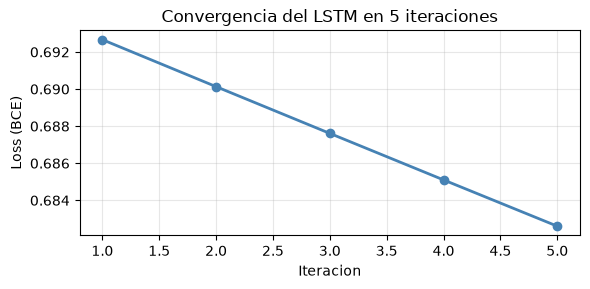

Grafica guardada como convergencia_lstm.png


In [17]:
if losses:
    plt.figure(figsize=(6,3))
    plt.plot(range(1, len(losses)+1), losses, 'o-', color='steelblue', linewidth=2)
    plt.xlabel('Iteracion'); plt.ylabel('Loss (BCE)')
    plt.title('Convergencia del LSTM en 5 iteraciones')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('convergencia_lstm.png', dpi=110, bbox_inches='tight')
    plt.show()
    print("Grafica guardada como convergencia_lstm.png")

---
## Bloque 10: Preguntas de analisis

Responda en las celdas Markdown habilitadas. Sus respuestas deben conectar los resultados numericos con los conceptos de clase. No es suficiente describir lo que ocurre: debe argumentar por que ocurre y que implicacion tiene.

---

### Pregunta 1 (35 pts de la seccion de analisis)

En el Bloque 6, el gradiente de $c_t$ se calcula con el operador `+=` en el paso 2:

```python
dL_dc = dL_dc_next + dL_dh * o_t * (1 - torch.tanh(c_t)**2)
```

a) Explique de donde viene cada uno de los dos terminos que se suman. ¿Que ruta del grafo de computo representa cada uno? Trace la ruta desde $L$ hasta $c_t$ para cada termino.

b) Si en su implementacion hubiera usado `=` en lugar de `+=`, ¿que informacion se perderia y como afectaria eso al entrenamiento? Razone en terminos del grafo de computo, no solo del codigo.

c) Compare esta acumulacion con lo que ocurria en el backward de la convolucion de la Semana 2, donde el gradiente del kernel tambien usaba `+=`. ¿Que tienen en comun los dos casos? ¿Que los hace diferentes?

**Su respuesta a la Pregunta 1:**

a)  Téxnicamente el estado de la celda actual influye en el resultado final del modelo a través de dos caminos distintos, por lo que al regresar en el tiempo debemos sumarlos ambos impactos. El primer término viene directamente del futuro,y este representa el error que se viene arrastrando desde los pasos de tiempo siguientes hacia atrás. El segundo término viene del presente, ya que el estado de la celda se usa en este mismo instante para calcular la salida actual de la neurona. Al sumar ambos, nos aseguramos de no ignorar ninguna de las dos influencias.

b)  Si usáramos un signo de igual en lugar de sumar, estaríamos borrando por completo toda la información del error que viene desde el futuro. En el grafo de cómputo, esto rompería la conexión entre los distintos pasos de tiempo. Como consecuencia, el entrenamiento fallaría porque la red se volvería "olvidadiza": solo aprendería de lo que pasa en el instante actual e ignoraría las relaciones a largo plazo, perdiendo la ventaja principal de una red LSTM.

c)  Lo que tienen en común es que en ambos casos una misma pieza de información se usa varias veces en la pasada hacia adelante, por lo que la regla matemática nos obliga a sumar todos sus efectos al ir hacia atrás. La diferencia es que en la convolución sumamos de manera espacial, acumulando el error de todas las posiciones donde el filtro tocó la imagen al mismo tiempo. En cambio, en la LSTM sumamos de manera temporal, uniendo el error que viaja a través del tiempo con el error de la salida actual.

---
### Pregunta 2 (35 pts de la seccion de analisis)

Considere una variante del LSTM donde la forget gate se fija en cero: $f_t = \mathbf{0}$ para todo $t$, sin aprender.

a) ¿Que le ocurre al cell state $c_t$ en cada paso de tiempo si $f_t = \mathbf{0}$? Escriba la ecuacion simplificada de $c_t$ y describa que tipo de memoria tiene el modelo resultante.

b) ¿Que le ocurre a la ruta directa del gradiente a traves del cell state? Muestre matematicamente como cambia $\frac{\partial c_t}{\partial c_{t-1}}$ y que consecuencia tiene eso para el aprendizaje de dependencias de largo plazo.

c) En su implementacion del Bloque 8, la loss decrecio monotonamente. ¿Ese comportamiento seguiria ocurriendo con $f_t = \mathbf{0}$? ¿Dependeria del largo de la secuencia $T$? Justifique.

**Su respuesta a la Pregunta 2:**

a)  Si la compuerta de olvido se fija en cero, la ecuación del estado de la celda se simplifica a la multiplicación de la compuerta de entrada por el candidato actual. Esto significa que la red borra por completo toda la información del pasado en cada paso de tiempo y solo guarda lo que entra en el instante actual. El modelo resultante pierde su memoria a largo plazo y se convierte en una memoria puramente reactiva a corto plazo, similar a una red neuronal estándar que no recuerda lo que pasó antes.

b) Al ser la compuerta de olvido igual a cero, la derivada del estado de la celda actual respecto al anterior se vuelve cero de forma matemática. Esto destruye la ruta directa del gradiente a través del tiempo. Como consecuencia para el aprendizaje, el modelo es incapaz de propagar los errores hacia atrás en secuencias largas, lo que causa un desvanecimiento inmediato del gradiente y hace imposible que la red aprenda dependencias o patrones de largo plazo.

c) **Sí seguiría decreciendo monótonamente, pero por una razón degenerada.** Hay que separar dos cosas que es fácil confundir:

**La monotonía no mide memoria, mide tamaño de paso.** La loss decrece en las 5 iteraciones porque $L$ es suave en los parámetros y $\alpha = 0.01$ es lo bastante chico como para que la aproximación de primer orden $L(\theta - \alpha\nabla L) \approx L(\theta) - \alpha\|\nabla L\|^2 < L(\theta)$ se cumpla en cada paso. Eso vale para cualquier modelo diferenciable con gradiente no nulo, tenga o no memoria. Además aquí solo hay **un ejemplo de entrenamiento con una sola etiqueta** ($y=1$): el problema es trivialmente ajustable, basta con que la red empuje $\hat{y}$ hacia arriba. Con $f_t = 0$ el gradiente sigue siendo distinto de cero (las rutas de $W_i$, $W_c$, $W_o$ y $W_{dense}$ siguen vivas), así que el descenso sigue funcionando y la curva seguiría bajando.

Una precisión sobre el inciso (a): con $f_t = 0$ la red no queda *totalmente* sin memoria. El cell state sí se borra, pero $h_{t-1}$ sigue entrando al `concat` de las cuatro compuertas, así que queda una recurrencia tipo RNN básica. Lo que se destruye es la *autopista protegida* del cell state, no toda la recurrencia. Y esa ruta residual es justo la que sufre el desvanecimiento del inciso (b).

**Sí dependería de $T$, y de una forma reveladora.** En nuestro Bloque 8 la loss bajó de 0.692664 a 0.682606 (una reducción de apenas 1.45% en 5 iteraciones), pero ese número lo produjo un modelo que sí integra los 5 pasos. Con $f_t = 0$:

- La **monotonía** se mantendría para cualquier $T$, porque solo depende de que $\alpha$ sea pequeño.
- La **velocidad** de la bajada se degradaría al crecer $T$. Con $c_t$ reseteado en cada paso, la única vía por la que la información de $x_1$ llega a $h_T$ es la cadena de $h$'s, que en 50 pasos se multiplica por un factor del orden de $\|W_h\|^{49} \approx 0.29^{49} \approx 10^{-27}$. En la práctica el gradiente que llega a los primeros pasos es cero numérico, y el modelo termina clasificando **solo con $x_T$**, ignorando la secuencia.
- La consecuencia conceptual: con $f_t = 0$ la curva de convergencia se vuelve casi **independiente de $T$**, porque el modelo colapsa a un clasificador estático sobre el último vector de entrada. Que la loss baje ya no es evidencia de que aprendió la *tendencia* (que es una propiedad de la secuencia completa); solo es evidencia de que memorizó a qué etiqueta corresponde $x_5 = [0.9, 1.0]$.

Es decir, una loss que decrece monótonamente **no es prueba de que el LSTM esté aprendiendo dependencias temporales**. Para distinguir un caso del otro habría que evaluar con secuencias que compartan el último paso pero difieran en la tendencia global, ahí el modelo con $f_t = 0$ fallaría y el LSTM completo no.

---
### Pregunta 3 (30 pts de la seccion de analisis)

Su implementacion del backward en el Bloque 6 acumula gradientes sobre los $T=5$ pasos de tiempo. Considere que la secuencia se extiende a $T=50$ pasos manteniendo el mismo patron creciente.

a) En la RNN basica, ¿como cambiaria el gradiente que llega a los pesos que procesaron el primer paso $t=1$ comparado con los que procesaron el ultimo paso $t=50$? Muestre el factor de escala usando la formula derivada en clase.

b) En el LSTM, ¿como afecta el aumento de $T$ a la ruta del gradiente a traves del cell state? ¿Que condicion sobre los valores de $f_t$ garantiza que el gradiente no se desvanezca en esa ruta?

c) En su implementacion actual del backward, el loop recorre $T$ pasos. Si $T$ aumenta de 5 a 50, ¿que cambia en el codigo y que permanece igual? ¿Hay algun riesgo numerico que deba considerar?

**Su respuesta a la Pregunta 3:**

a) Para que el error llegue del final de la secuencia hasta el primer paso, tiene que atravesar todos los pasos intermedios, y en cada cruce queda multiplicado por el mismo factor:

$$\frac{\partial h_t}{\partial h_{t-1}} = \text{diag}(1-\tanh^2(z_t))\, W_h$$

Entonces la diferencia entre el primer paso y el último es cuántas veces se aplica esa multiplicación. Con $T=50$, el último paso no atraviesa nada (factor $=1$, recibe el gradiente completo) y el primero atraviesa 49 pasos, así que su factor de escala es:

$$\prod_{k=2}^{50} \text{diag}(1-\tanh^2(z_k))\, W_h \;\approx\; (\gamma \|W_h\|)^{49}$$

Como el exponente crece con $T$, solo hay dos finales posibles: si $\gamma\|W_h\| < 1$ el factor se va a cero (**gradiente que se desvanece**) y si es mayor que 1 se dispara (**gradiente que explota**). Con nuestra inicialización $\|W_h\| \approx 0.29$, y $0.29^{49}$ es del orden de $10^{-27}$, o sea cero en la práctica: el último paso aprendería normal y el primero no aprendería nada.

b) En el LSTM la ruta del cell state es mucho más simple. Como $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$:

$$\frac{\partial c_t}{\partial c_{t-1}} = \text{diag}(f_t) \qquad\Longrightarrow\qquad \frac{\partial c_T}{\partial c_t} = \prod_{k=t+1}^{T} \text{diag}(f_k)$$

Es lo que escribimos en el Bloque 6 con `dL_dc_next = dL_dc * f_t`. Lo importante es lo que **no** aparece: no hay $W_h$ ni derivada de tanh, solo el producto de las forget gates. De ahí sale la condición: **el gradiente sobrevive si $f_k$ está cerca de 1 en todos los pasos**. Tiene sentido intuitivo, $f_k \approx 1$ significa "no olvides nada", y si la red no olvida hacia adelante tampoco pierde el gradiente hacia atrás.

Nuestra inicialización no cumple eso: con $b_f = 0$ las forget gates salieron alrededor de 0.5, y $0.5^{49} \approx 10^{-15}$, así que también se desvanece. Aun así es mucho mejor que el $10^{-27}$ de la RNN, justamente porque se ahorra el $\|W_h\|$ en cada paso. Y aquí hay arreglo fácil: inicializar $b_f$ positivo (1 o 2) para que las compuertas arranquen cerca de 0.8.

c) **Cambia** solo el valor de `T` y el tamaño de `x_seq`. Lo demás se ajusta solo: `all_caches` guardaría 50 caches y los loops darían 50 vueltas. El costo crece lineal, el doble de pasos es el doble de trabajo.

**No cambia** nada del código ni las formas de los pesos: $W_f, W_i, W_c, W_o$ siguen siendo $(4,6)$, igual que sus gradientes. Esto es porque los pesos **se comparten entre pasos de tiempo**: una secuencia más larga no agrega parámetros, solo acumula más sumandos sobre los mismos.

**Riesgos:**

1. **Desvanecimiento**: con $f_t \approx 0.5$ los primeros pasos recibirían gradiente de $10^{-15}$. No da error, y ese es el peligro: parece que entrena pero la red ignora el inicio de la secuencia. Se arregla con $b_f > 0$.
2. **Explosión**: si los pesos crecen, la amplificación se repite 50 veces y puede terminar en `NaN`. Se controla con *gradient clipping*.
3. **Learning rate**: ahora se acumulan 50 sumandos en vez de 5, así que el gradiente total puede ser mayor y $\alpha = 0.01$ podría dejar de garantizar la bajada monótona del Bloque 8. Convendría bajarlo.
4. **Memoria**: guardar el cache de todos los pasos escala mal si la secuencia fuera de miles; ahí se usa *truncated BPTT*.

---
## Bloque 11: Nota automatica sobre la seccion de codigo

In [18]:
# NOTA AUTOMATICA - no modificar
_PUNTOS = {
    'b2': ('Bloque 2:  Forward pass secuencia completa',    18),
    'b3': ('Bloque 3:  Capa densa + sigmoid',                8),
    'b4': ('Bloque 4:  Perdida BCE',                         7),
    'b6': ('Bloque 6:  Backward LSTM (BPTT)',               12),
    'b7': ('Bloque 7:  Actualizacion de pesos',              5),
    'b8': ('Bloque 8:  Convergencia en 5 iteraciones',       3),
}
_TOTAL = 53

print("=" * 60)
print("  NOTA AUTOMATICA - SECCION DE CODIGO")
print("=" * 60)
_obtenido = 0
for key, (nombre, pts_max) in _PUNTOS.items():
    ok  = _resultados.get(key, False)
    pts = pts_max if ok else 0
    _obtenido += pts
    estado = "CORRECTO" if ok else "PENDIENTE"
    print(f"  {estado:10s} | {nombre:40s} | {pts:2d}/{pts_max} pts")

print("-" * 60)
print(f"  Subtotal codigo:   {_obtenido}/{_TOTAL} puntos")
print()
print("  Pendiente de calificacion manual:")
print("    Bloque 10 - Preguntas de analisis : __/30 pts")
print("    Comentarios en el codigo          : __/17 pts")
print("-" * 60)
print("  TOTAL FINAL (sobre 100):             __/100 pts")
print("=" * 60)

if _obtenido == _TOTAL:
    print("\n  Todos los bloques de codigo son correctos.")
elif _obtenido == 0:
    print("\n  Ninguna implementacion verificada. Ejecute los bloques en orden.")
else:
    pendientes = [n for k,(n,_) in _PUNTOS.items() if not _resultados.get(k,False)]
    print("\n  Bloques pendientes:")
    for p in pendientes:
        print(f"    - {p}")

  NOTA AUTOMATICA - SECCION DE CODIGO
  CORRECTO   | Bloque 2:  Forward pass secuencia completa | 18/18 pts
  CORRECTO   | Bloque 3:  Capa densa + sigmoid          |  8/8 pts
  CORRECTO   | Bloque 4:  Perdida BCE                   |  7/7 pts
  CORRECTO   | Bloque 6:  Backward LSTM (BPTT)          | 12/12 pts
  CORRECTO   | Bloque 7:  Actualizacion de pesos        |  5/5 pts
  CORRECTO   | Bloque 8:  Convergencia en 5 iteraciones |  3/3 pts
------------------------------------------------------------
  Subtotal codigo:   53/53 puntos

  Pendiente de calificacion manual:
    Bloque 10 - Preguntas de analisis : __/30 pts
    Comentarios en el codigo          : __/17 pts
------------------------------------------------------------
  TOTAL FINAL (sobre 100):             __/100 pts

  Todos los bloques de codigo son correctos.
